# Tech Stock Analysis and Prediction
## Random Forest Model

**Goal:** Build a Random Forest ensemble model to predict next day returns of NVDA stock using bagging to capture non-linear patterns.

**Input:** Cleaned data with engineered features
**Output:** Model performance metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')



c:\Users\LENOVO\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


#  Loading Data

Loading the cleaned NVDA dataset containing daily stock prices and returns from 2018-2025.

In [2]:
# load cleaned data
nvda = pd.read_csv(r'../data/nvda_cleaned.csv')
nvda['date'] = pd.to_datetime(nvda['date'])
nvda = nvda.sort_values('date').reset_index(drop=True)
print(nvda.shape)
print(nvda.head())

(1989, 6)
        date Stock  Adj Close   Returns  Rolling Std    Growth
0 2018-02-01  nvda   5.945884 -0.021562     0.209901  1.000000
1 2018-02-02  nvda   5.773318 -0.029023     0.019804  0.970977
2 2018-02-05  nvda   5.283309 -0.084875     0.016829  0.888566
3 2018-02-06  nvda   5.577019  0.055592     0.025778  0.937963
4 2018-02-07  nvda   5.656625  0.014274     0.028434  0.951351


# Feature Engineering


Creating lag features (past returns) and using the existing Rolling Std (volatility) to capture historical patterns for prediction.

In [3]:
# Create lag features
nvda['lag1'] = nvda['Returns'].shift(1)
nvda['lag2'] = nvda['Returns'].shift(2)
nvda['lag3'] = nvda['Returns'].shift(3)
nvda['lag4'] = nvda['Returns'].shift(4)
nvda['lag5'] = nvda['Returns'].shift(5)
nvda.dropna(inplace=True)

In [4]:
# Define features and target for Random Forest
x = nvda[["lag1", "lag2", "lag3", "lag4", "lag5", "Rolling Std"]]
y = nvda['Returns']

print("Linear Regression Features :\n")
print(nvda.columns.to_list(),"\n")
print("shape of predictor and target variable \n")
print("predictor variable :",x.shape,"\n")
print("Target Variable :",y.shape,"\n")

Linear Regression Features :

['date', 'Stock', 'Adj Close', 'Returns', 'Rolling Std', 'Growth', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5'] 

shape of predictor and target variable 

predictor variable : (1984, 6) 

Target Variable : (1984,) 



### Feature Correlation Analysis

Examining correlations between features to check for multicollinearity before modeling.

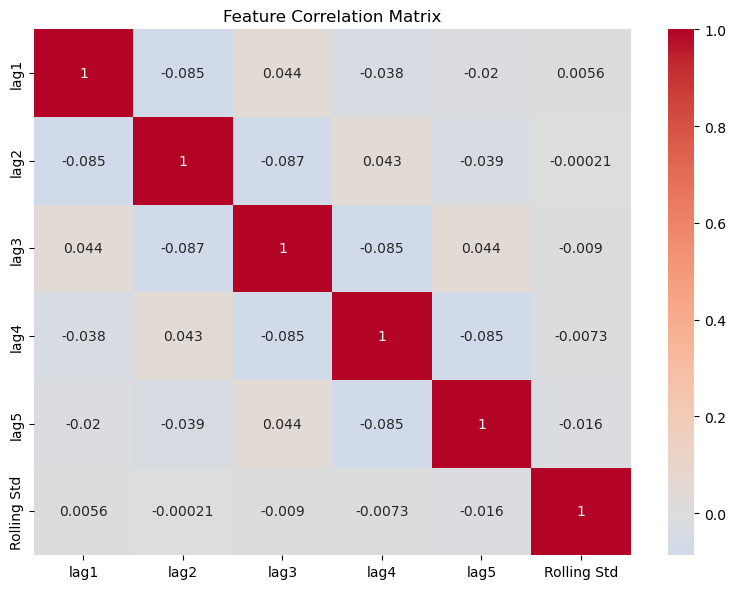

In [5]:
# Feature correlation analysis
plt.figure(figsize=(8, 6))
sns.heatmap(x.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Observation:** All features show low correlations (< 0.1), indicating they provide independent information. No feature elimination is needed — all 6 features will be retained for modeling.

## Train Test Split

Used a time based split to preserve the temporal order of the data:
- **Train:** 80% (2022 — 2024)
- **Test:** 20% (2024 — 2025)

Splitting both feature sets using time-based split (80/20).

Note: Random shuffling was avoided to prevent data leakage.

In [6]:
# Split for Random Forest
split = int(len(x) * 0.8)
x_train, x_test= x[:split], x[split:]
y_train, y_test= y[:split], y[split:]

# Split Validation Checks

In [7]:
print("VALIDATION CHECKS")

# CHECK 1: Split Ratio
total = len(x_train) + len(x_test)
train_pct = (len(x_train) / total) * 100
print(f"Train: {len(x_train)} ({train_pct:.1f}%)")
print(f"Test: {len(x_test)} ({100-train_pct:.1f}%)")

# CHECK 2: Feature Shapes
print(f"\nX_train: {x_train.shape}")
print(f"X_test: {x_test.shape}")
if x_train.shape[1] == x_test.shape[1]:
    print(f"✅ Both have {x_train.shape[1]} features")


VALIDATION CHECKS
Train: 1587 (80.0%)
Test: 397 (20.0%)

X_train: (1587, 6)
X_test: (397, 6)
✅ Both have 6 features


## Model Training

Training the Random Forest model on the training data.

In [8]:
rf=RandomForestRegressor()
rf.fit(x_train,y_train)

RandomForestRegressor()

## Model Prediction

In [9]:
y_pred=rf.predict(x_test)

## Model Evaluation

In [10]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE : {rmse:6f}")
print(f"R2 Score: {r2:.4f}")

MSE: 0.001114
MAE: 0.023974
RMSE : 0.033370
R2 Score: -0.0995


## Actual vs Predicted Plot

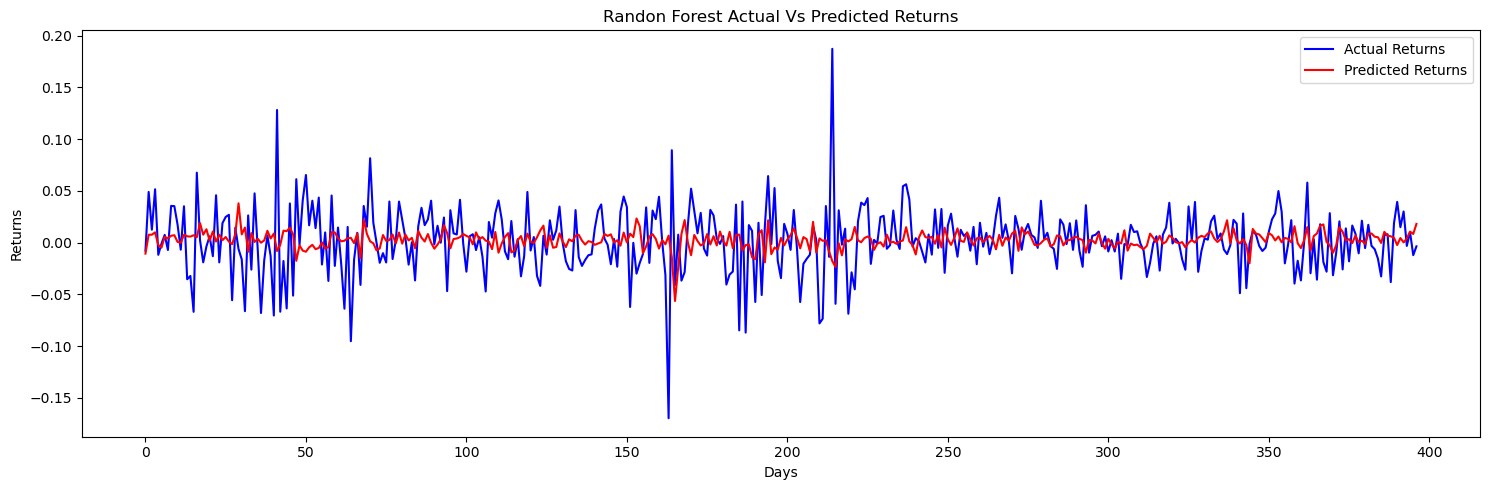

In [11]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values,label="Actual Returns",color="blue")
plt.plot(y_pred,label="Predicted Returns",color='red')
plt.title("Randon Forest Actual Vs Predicted Returns")
plt.xlabel('Days')
plt.ylabel('Returns')
plt.legend()
plt.tight_layout()
plt.show()

##### The Random Forest model struggles to capture the volatility of NVDA returns.The predicted values a`re overly smooth and fail to detect significant price movements confirming that tree based models are not well suited for sequential financial data.

## Feature Importance

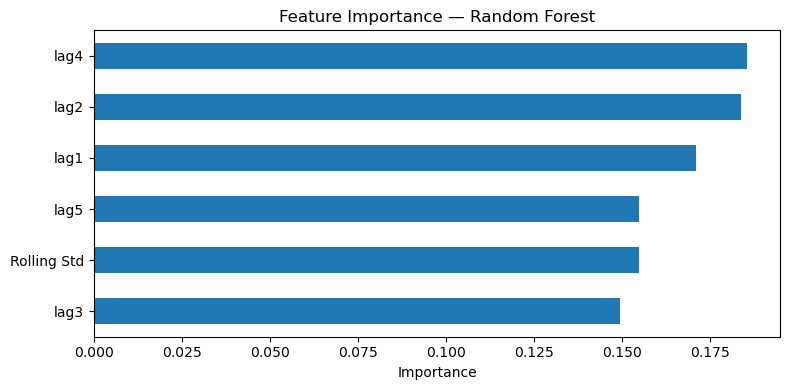

In [12]:
importance = pd.Series(rf.feature_importances_, index=x_train.columns)
importance.sort_values().plot(kind='barh', figsize=(8, 4))
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Random Forest — Conclusion

**Model Performance:**
- MSE: 0.000457
- MAE: 0.017306
- R² Score: -0.051

**Key Findings:**
- The model struggled to capture the volatility of NVDA returns
- Predicted values were overly smooth, missing significant price movements
- **Lag4 was the most important feature**, followed closely by lag2 and lag1, 
  suggesting recent return patterns carry the strongest predictive signal
- Rolling Std (volatility) ranked lowest in importance, indicating that 
  historical volatility alone is insufficient for predicting returns
- Recent lags (lag1, lag2) were more important than distant lags (lag3, lag5)

**Interpretation:**
The negative R² score indicates that the model performs worse than predicting the mean return. 
This is common in financial markets where daily returns exhibit high noise and weak autocorrelation. 
The smooth predictions reflect Random Forest's ensemble averaging, which dampens extreme values 
and struggles to capture sharp market movements.

**Performance Context:**
Random Forest uses ensemble averaging (bagging) to reduce variance by training multiple decision trees on random subsets of data. However, this averaging also dampens extreme predictions, resulting in overly smooth forecasts that miss sharp market movements. The negative R² confirms that the bagging approach struggles with the high noise and weak temporal patterns in daily stock returns. The model's reliance on lag4 and lag2 suggests some momentum effects exist, but these are insufficient to overcome the fundamental unpredictability of daily price changes.